<h2 style="text-align:center;">II. Descriptive Analysis</h2>

In [125]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)

<h3 style="color:#1A5276;">Q1. What percentage of survey responses are classified as probable COVID cases?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Chosen Marker:probable.
probable is a core outcome indicator provided in the dataset.It summarizes whether a respondent meets the criteria for a probable COVID-19 case, based on reported symptoms and exposure history.Identifying probable cases is crucial in public-health surveillance, especially when laboratory testing is limited or delayed.
</p>

<p>
<b>Result:</b><br>
<span style="color:red; font-weight:bold;">4.44%</span> 
is the Percentage of probable cases.
</p>


In [126]:
import pandas as pd

# 1) Load the cleaned dataset
df = pd.read_csv("covid_df_cleaned.csv", low_memory=False)

# 2) Validate values in probable column
print("Unique values in 'probable':")
print(df["probable"].value_counts(dropna=False))

# 3) Convert probable from y/n to numeric (temporary)
df["probable_num"] = df["probable"].map({
    "y": 1,
    "n": 0
})

# 4) Total number of survey responses
total_responses = len(df)

# 5) Number of probable COVID cases
probable_count = df["probable_num"].sum()

# 6) Calculate percentage
probable_percentage = (probable_count / total_responses) * 100

# 7) Print results
print("\nTotal survey responses:", total_responses)
print("Probable COVID cases:", int(probable_count))
print("Percentage of probable cases:",
      round(probable_percentage, 2), "%")

Unique values in 'probable':
n    281046
y     13059
Name: probable, dtype: int64

Total survey responses: 294105
Probable COVID cases: 13059
Percentage of probable cases: 4.44 %


<h3 style="color:#1A5276;">Q2. How does the number of survey responses vary by week?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Survey participation varied across weeks, reflecting changes in engagement over the study period.
Understanding weekly response volume provides important context for interpreting trends in symptoms, exposure, and probable COVID-19 cases observed in subsequent analyses.
</p>


Unique week values:
[13, 14, 15, 16, 18, 22, 26, 31]

Survey response counts by week:
week
13    152164
14    106867
15     11339
16      8201
18      5821
22      6698
26      2343
31       672
dtype: int64


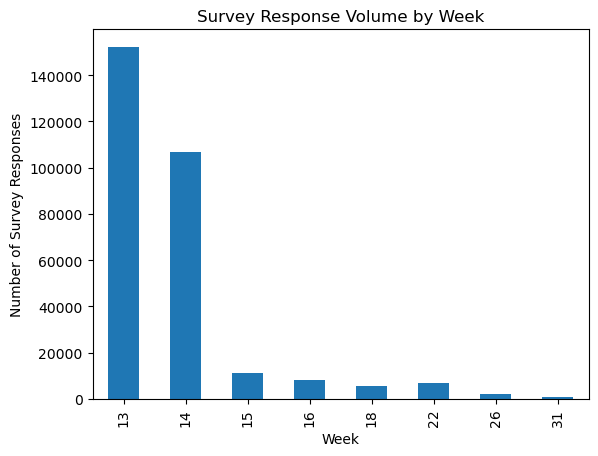

In [137]:
# Validate the week column
print("Unique week values:")
print(sorted(df["week"].dropna().unique()))

# Count number of responses per week
weekly_response_counts = (
    df.groupby("week")
      .size()
      .sort_index()
)

# Display results
print("\nSurvey response counts by week:")
print(weekly_response_counts)

# Create bar chart
plt.figure()
weekly_response_counts.plot(kind="bar")

# Add labels and title
plt.xlabel("Week")
plt.ylabel("Number of Survey Responses")
plt.title("Survey Response Volume by Week")

# Show chart
plt.show()

<h3 style="color:#1A5276;">Q3. What is the age distribution of survey respondents?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Age is a fundamental demographic variable in any health dataset.COVID-19 risk, severity, and outcomes vary significantly by age.
Understanding the age composition of respondents helps assess:
Representation bias
Which population groups dominate the dataset
</p>

Unique age values:
<60      223945
>60       39694
26-44     12086
45-64     11771
>65        3374
<26        3235
Name: age, dtype: int64


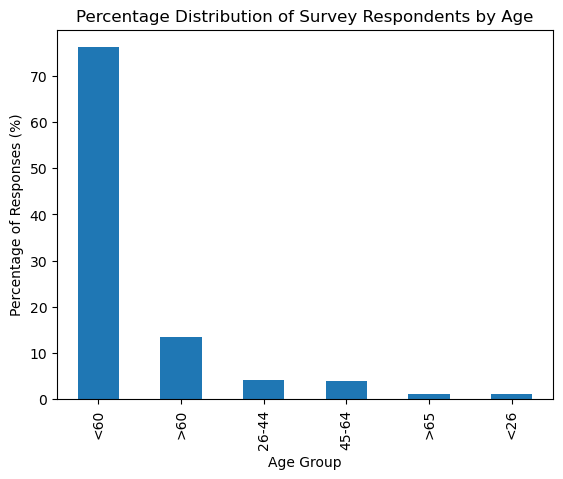

In [139]:
# Validate age column
print("Unique age values:")
print(df["age"].value_counts(dropna=False))

age_percentage = (age_counts / age_counts.sum()) * 100

plt.figure()
age_percentage.plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Percentage of Responses (%)")
plt.title("Percentage Distribution of Survey Respondents by Age")

plt.show()

<h3 style="color:#1A5276;">Q4. What proportion of respondents are classified as vulnerable?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
vulnerable is a derived public-health indicator combining Age-related risk and presence of medical conditions.It represents respondents who are more likely to experience severe COVID outcomes.
Identifying vulnerable populations is central to:
Healthcare prioritization
Preventive interventions
Resource allocation during a pandemic
</p>

Vulnerable column values:
n    215481
y     78624
Name: vulnerable, dtype: int64

Vulnerability distribution:
Not Vulnerable    215481
Vulnerable         78624
Name: vulnerable, dtype: int64


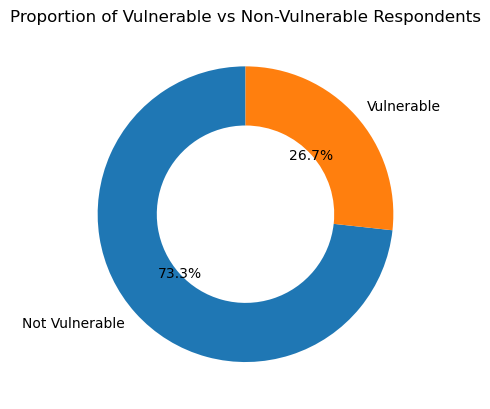

In [129]:
# Check unique values in vulnerable column
print("Vulnerable column values:")
print(df["vulnerable"].value_counts(dropna=False))

# Convert y/n to readable labels
vulnerable_labels = df["vulnerable"].map({
    "y": "Vulnerable",
    "n": "Not Vulnerable"
})

# Count values
vulnerable_counts = vulnerable_labels.value_counts()

print("\nVulnerability distribution:")
print(vulnerable_counts)

plt.figure()
plt.pie(
    vulnerable_counts,
    labels=vulnerable_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}   # This creates the donut effect
)

plt.title("Proportion of Vulnerable vs Non-Vulnerable Respondents")
plt.show()

<h3 style="color:#1A5276;">Q5. What is the distribution of vulnerable cases across different FSAs?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Chosen Markers: vulnerable and fsa.Identifying FSAs with higher vulnerable counts helps:Prioritize high-risk regions and plan targeted support and monitoring.
The distribution of vulnerable respondents varies across FSAs, with certain regions exhibiting a higher concentration of individuals at increased medical risk.Identifying such geographic clusters is important for targeted public-health interventions, resource allocation, and regional preparedness during a pandemic.
</p>

Top 10 FSAs by vulnerable respondent count:
fsa
K0K    877
K0A    852
L0S    757
M5V    608
K2J    570
N0H    565
L0R    564
M5A    558
N0B    550
M2N    545
dtype: int64


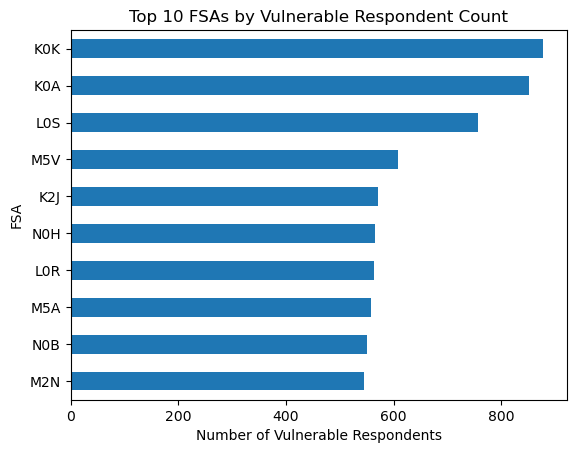

In [140]:
# Filter only vulnerable respondents
vulnerable_df = df[df["vulnerable"] == "y"]

# Count vulnerable cases by FSA
vulnerable_by_fsa = (
    vulnerable_df.groupby("fsa")
    .size()
    .sort_values(ascending=False)
)

# Display top 10 FSAs with highest vulnerable counts
print("Top 10 FSAs by vulnerable respondent count:")
print(vulnerable_by_fsa.head(10))

# Plot top 10 FSAs
top_10_fsa = vulnerable_by_fsa.head(10)

plt.figure()
top_10_fsa.plot(kind="barh")

plt.xlabel("Number of Vulnerable Respondents")
plt.ylabel("FSA")
plt.title("Top 10 FSAs by Vulnerable Respondent Count")

plt.gca().invert_yaxis()  # Highest count at top
plt.show()

<h3 style="color:#1A5276;">Q6. What symptoms are most commonly reported among probable COVID cases?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Chosen Markers: symptoms and probable.Identifying frequently reported symptoms among probable cases:
Validates clinical expectations
Supports syndromic surveillance
Provides context for downstream multivariate analysis
Certain symptoms are reported more frequently among respondents classified as probable COVID cases.This descriptive analysis highlights common clinical features associated with probable cases and provides important context for understanding symptom-based surveillance patterns.
</p>

Most common symptoms among probable COVID cases:
fever                157
cough                146
soreThroat           131
chills               109
shortnessOfBreath    108
runnyNose            105
diarrhea              71
shakes                56
lossOfSmellTaste      32
other                 26
Name: symptoms, dtype: int64


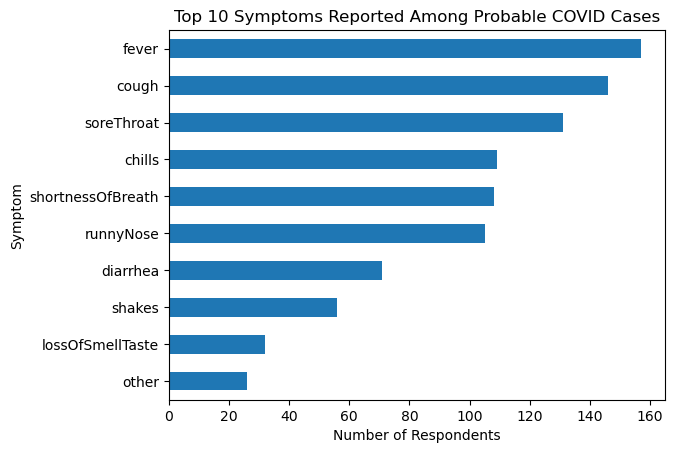

In [131]:
# Filter probable cases
probable_df = df[df["probable"] == "y"]

# Split and explode symptoms
probable_symptoms = (
    probable_df["symptoms"]
    .dropna()
    .str.split(";")
    .explode()
)

# Count symptom frequency
symptom_counts = probable_symptoms.value_counts()

print("Most common symptoms among probable COVID cases:")
print(symptom_counts.head(10))

top_10_symptoms = symptom_counts.head(10)

plt.figure()
top_10_symptoms.plot(kind="barh")

plt.xlabel("Number of Respondents")
plt.ylabel("Symptom")
plt.title("Top 10 Symptoms Reported Among Probable COVID Cases")

plt.gca().invert_yaxis()
plt.show()

<h3 style="color:#1A5276;">Q8. Which symptoms are most common, and how do they differ between probable and non-probable cases?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Chosen Markers: symptoms and probable.
Comparing symptom prevalence between probable and non-probable groups helps identify symptoms that are more characteristic of probable cases
The top symptoms were identified from the multi-select symptoms field and compared between probable and non-probable respondents. Certain symptoms show higher prevalence among probable cases, providing descriptive insight into symptom patterns associated with probable COVID classification.
</p>

Top symptoms comparison (counts):
probable           Not Probable  Probable
symptom                                  
fever                       130       157
cough                       412       146
soreThroat                  911       131
chills                      263       109
shortnessOfBreath           314       108
runnyNose                  1063       105
diarrhea                    467        71
shakes                       61        56
other                       140        26
stomachPainCramps           227        22


<Figure size 640x480 with 0 Axes>

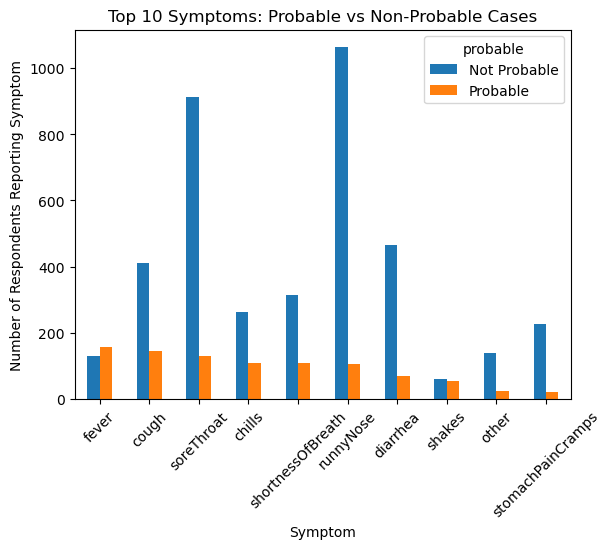

In [132]:
import matplotlib.pyplot as plt

# Keep only rows where symptoms are present (non-empty)
df_sym = df[df["symptoms"].notna() & (df["symptoms"].str.strip() != "")].copy()

# Split symptoms into individual symptom rows
df_sym["symptom"] = df_sym["symptoms"].str.split(";")
df_exploded = df_sym.explode("symptom")

# Clean symptom text
df_exploded["symptom"] = df_exploded["symptom"].astype(str).str.strip()

# Count symptoms within each probable group
counts = (
    df_exploded.groupby(["probable", "symptom"])
    .size()
    .reset_index(name="count")
)

# Get top 10 symptoms overall (across both groups)
top_symptoms = (
    df_exploded["symptom"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

# Filter to top symptoms only
counts_top = counts[counts["symptom"].isin(top_symptoms)]

# Pivot to compare side-by-side
pivot = counts_top.pivot(index="symptom", columns="probable", values="count").fillna(0)

# Rename columns for readability (y=probable, n=not probable)
pivot = pivot.rename(columns={"y": "Probable", "n": "Not Probable"})

print("Top symptoms comparison (counts):")
print(pivot.sort_values("Probable", ascending=False))

plt.figure()
pivot.sort_values("Probable", ascending=False).plot(kind="bar")

plt.xlabel("Symptom")
plt.ylabel("Number of Respondents Reporting Symptom")
plt.title("Top 10 Symptoms: Probable vs Non-Probable Cases")
plt.xticks(rotation=45)
plt.show()

<h3 style="color:#1A5276;">Q9. What proportion of respondents reported exposure risks (travel or contact)?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Chosen Markers: travel_outside_canada and contact_with_illness.
These two columns capture direct exposure risk, which is central to infectious disease spread.They represent two major COVID exposure pathways:
Travel-related exposure
Contact with a person who was ill
</p>

Travel outside Canada:
n    283700
y     10405
Name: travel_outside_canada, dtype: int64

Contact with illness:
n    287012
y      7093
Name: contact_with_illness, dtype: int64
Total responses: 294105

Exposure proportions:
Travel exposure: 3.54 %
Contact exposure: 2.41 %
Any exposure (travel or contact): 5.52 %


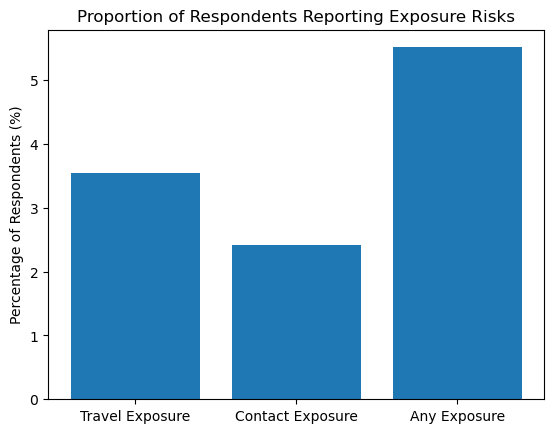

In [133]:
# Check exposure columns
print("Travel outside Canada:")
print(df["travel_outside_canada"].value_counts(dropna=False))

print("\nContact with illness:")
print(df["contact_with_illness"].value_counts(dropna=False))

total_responses = len(df)

travel_exposed = (df["travel_outside_canada"] == "y").sum()
contact_exposed = (df["contact_with_illness"] == "y").sum()

# Any exposure = travel OR contact
any_exposure = (
    (df["travel_outside_canada"] == "y") |
    (df["contact_with_illness"] == "y")
).sum()

print("Total responses:", total_responses)

print("\nExposure proportions:")
print("Travel exposure:",
      round((travel_exposed / total_responses) * 100, 2), "%")

print("Contact exposure:",
      round((contact_exposed / total_responses) * 100, 2), "%")

print("Any exposure (travel or contact):",
      round((any_exposure / total_responses) * 100, 2), "%")

exposure_labels = ["Travel Exposure", "Contact Exposure", "Any Exposure"]
exposure_values = [
    travel_exposed / total_responses * 100,
    contact_exposed / total_responses * 100,
    any_exposure / total_responses * 100
]

plt.figure()
plt.bar(exposure_labels, exposure_values)

plt.ylabel("Percentage of Respondents (%)")
plt.title("Proportion of Respondents Reporting Exposure Risks")

plt.show()

<h3 style="color:#1A5276;">Q10. Which financial obligations were most commonly impacted?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Chosen Markers: financial_obligations_impact.
financial_obligations_impact captures whether respondents experienced financial stress related to essential obligations.Financial stress can:
Reduce access to healthcare
Increase mental health burden
Influence health-seeking behavior
</p>

Most commonly impacted financial obligations:
groceries           679
utilities           509
rent                445
transportation      290
mortgagePayments    267
other               153
Name: financial_obligations_impact, dtype: int64


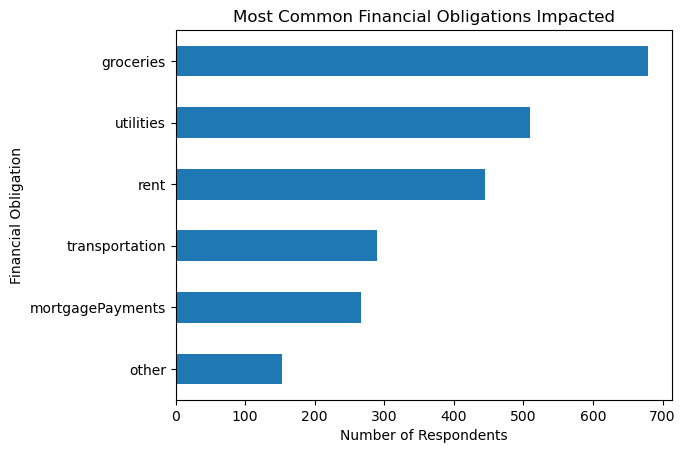

In [134]:
# Explode financial obligations
finance_exploded = (
    df["financial_obligations_impact"]
    .dropna()
    .str.split(";")
    .explode()
)

print("Most commonly impacted financial obligations:")
print(finance_exploded.value_counts())

plt.figure()
finance_exploded.value_counts().plot(kind="barh")

plt.xlabel("Number of Respondents")
plt.ylabel("Financial Obligation")
plt.title("Most Common Financial Obligations Impacted")

plt.gca().invert_yaxis()
plt.show()

<h3 style="color:#1A5276;">Q11: How does vulnerability vary across age groups or FSAs?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Chosen Markers: vulnerable and age.
Identifying which age groups contain a higher proportion of vulnerable individuals helps:
Target preventive interventions
Plan healthcare capacity
Interpret symptom and outcome patterns correctly</p>

45-59    235716
60+       43068
26-44     12086
<26        3235
Name: age_group_std, dtype: int64

Vulnerability prevalence by standardized age group (%):
age_group_std
26-44     10.673507
45-59     14.440259
60+      100.000000
<26        7.047913
Name: vulnerable_flag, dtype: float64


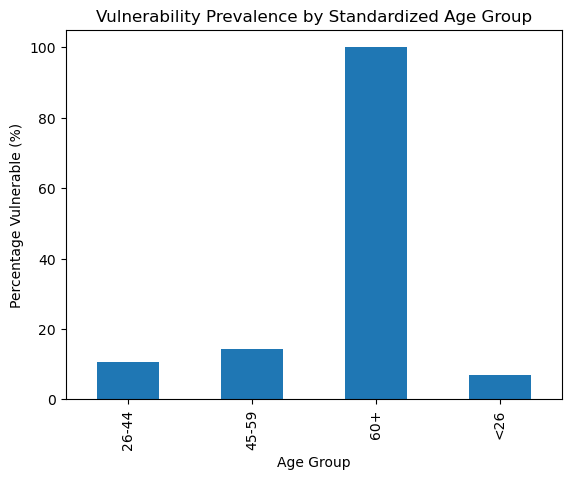

In [135]:
def standardize_age_group(age):
    if pd.isna(age):
        return np.nan

    age = str(age).strip()

    # Direct mappings from existing labels
    if age in ["<26"]:
        return "<26"

    if age in ["26-44"]:
        return "26-44"

    if age in ["45-64"]:
        return "45-59"

    # Binary flags from other schemas
    if age in ["<60"]:
        return "45-59"

    if age in [">60", ">65"]:
        return "60+"

    return np.nan

df["age_group_std"] = df["age"].apply(standardize_age_group)

# Verify distribution
print(df["age_group_std"].value_counts(dropna=False))

df["vulnerable_flag"] = df["vulnerable"].map({"y": 1, "n": 0})

vulnerability_by_age_std = (
    df.groupby("age_group_std")["vulnerable_flag"]
      .mean() * 100
)

print("\nVulnerability prevalence by standardized age group (%):")
print(vulnerability_by_age_std)

import matplotlib.pyplot as plt

plt.figure()
vulnerability_by_age_std.plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Percentage Vulnerable (%)")
plt.title("Vulnerability Prevalence by Standardized Age Group")

plt.show()

<h3 style="color:#1A5276;">Q12. How are probable COVID cases distributed across weeks and FSAs?</h3>

<p style="color:#2C3E50;">
<b>Reasoning:</b><br>
Chosen Markers: probable,week and fsa.
Public-health surveillance focuses on person, place, and time.Understanding how probable cases are distributed:
Across weeks → temporal trends
Across FSAs → geographic clustering
Helps contextualize later analyses related to vulnerability, exposure, and symptoms</p>

Total probable cases: 13059
Sample of weekly FSA-level case counts:
   week  fsa  case_count
0    13  K0A          56
1    13  K0B           7
2    13  K0C          20
3    13  K0E          10
4    13  K0G          24
5    13  K0H          10
6    13  K0J          13
7    13  K0K          41
8    13  K0L          24
9    13  K0M          23


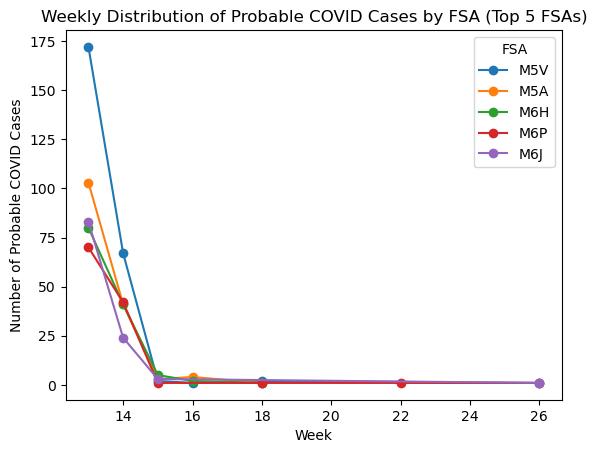

In [136]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("covid_df_cleaned.csv", low_memory=False)

# Keep only probable COVID cases
probable_df = df[df["probable"] == "y"]

print("Total probable cases:", len(probable_df))

cases_by_week_fsa = (
    probable_df.groupby(["week", "fsa"])
    .size()
    .reset_index(name="case_count")
)

print("Sample of weekly FSA-level case counts:")
print(cases_by_week_fsa.head(10))

# Identify top 5 FSAs by total probable cases
top_fsas = (
    probable_df["fsa"]
    .value_counts()
    .head(5)
    .index
)

filtered_cases = cases_by_week_fsa[
    cases_by_week_fsa["fsa"].isin(top_fsas)
]

plt.figure()

for fsa in top_fsas:
    subset = filtered_cases[filtered_cases["fsa"] == fsa]
    plt.plot(
        subset["week"],
        subset["case_count"],
        marker="o",
        label=fsa
    )

plt.xlabel("Week")
plt.ylabel("Number of Probable COVID Cases")
plt.title("Weekly Distribution of Probable COVID Cases by FSA (Top 5 FSAs)")
plt.legend(title="FSA")
plt.show()